In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print(df.shape)
print(df.columns.tolist())
df.head()

(9994, 27)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin', 'delivery dates ', 'Delivery Days', 'Profit Margin %', 'Year', 'Month']


/tmp/ipykernel_25596/2122283272.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_25596/2122283272.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Profit Margin,delivery dates,Delivery Days,Profit Margin %,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,16.00,3,3,16.00,2016,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,30.00,3,3,30.00,2016,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,47.00,4,4,47.00,2016,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,-40.00,7,7,-40.00,2015,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,11.25,7,7,11.25,2015,2015-10


In [6]:
print("Null values:")
print(df.isnull().sum())
print()
print("Basic Stats:")
df.describe()

Null values:
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Profit Margin      0
delivery dates     0
Delivery Days      0
Profit Margin %    0
Year               0
Month              0
dtype: int64

Basic Stats:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,delivery dates,Delivery Days,Profit Margin %,Year
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,12.031393,3.958175,3.958175,12.031393,2015.722233
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-275.000000,0.000000,0.000000,-275.000000,2014.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,7.500000,3.000000,3.000000,7.500000,2015.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,27.000000,4.000000,4.000000,27.000000,2016.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,36.250000,5.000000,5.000000,36.250000,2017.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,50.000000,7.000000,7.000000,50.000000,2017.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,46.675435,1.747567,1.747567,46.675435,1.123555


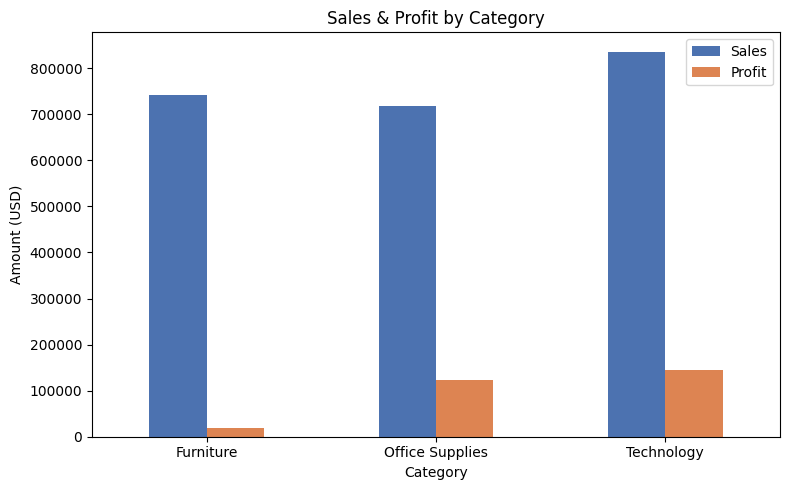

In [7]:
cat = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
cat.plot(x='Category', kind='bar', figsize=(8,5), color=['#4C72B0','#DD8452'])
plt.title('Sales & Profit by Category')
plt.ylabel('Amount (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_sales_profit.png')
plt.show()

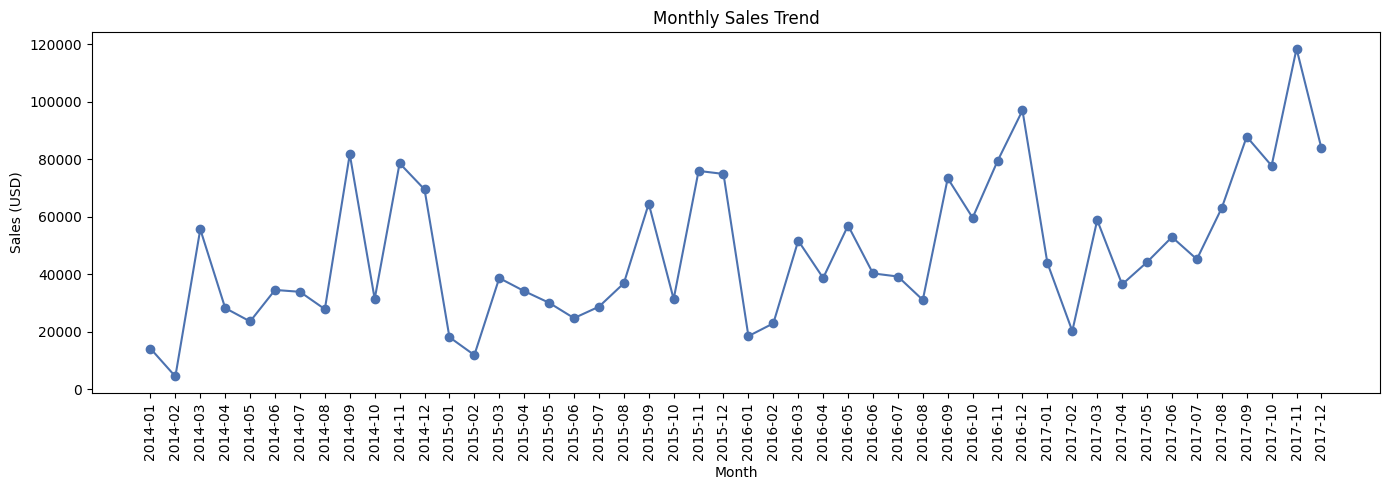

In [8]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)
plt.figure(figsize=(14,5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o', color='#4C72B0')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

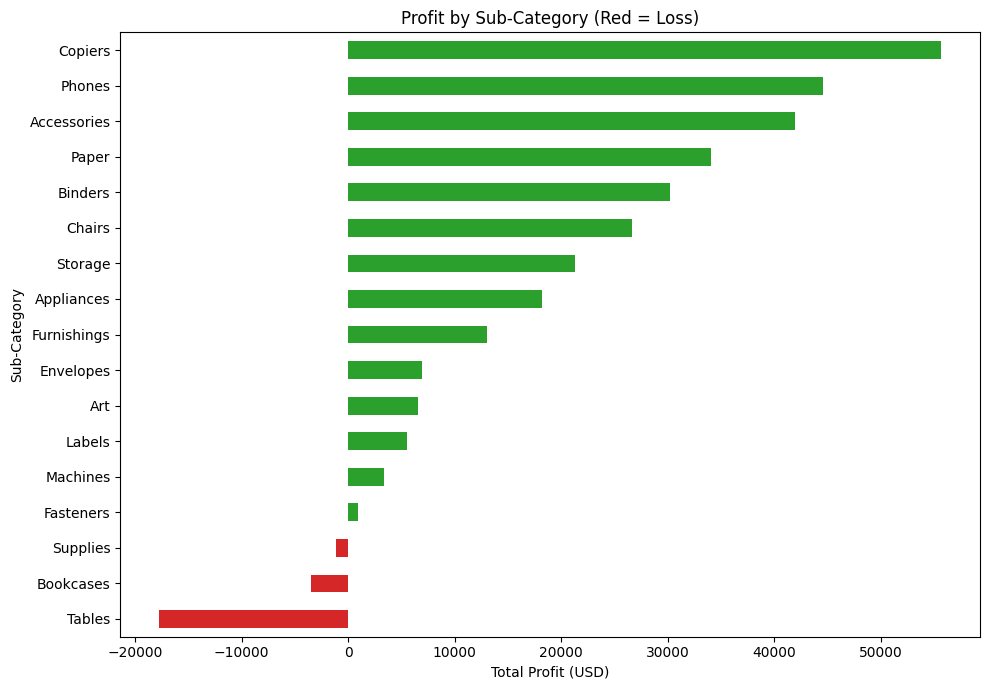

In [9]:
sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in sub]
plt.figure(figsize=(10,7))
sub.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category (Red = Loss)')
plt.xlabel('Total Profit (USD)')
plt.tight_layout()
plt.savefig('subcategory_profit.png')
plt.show()

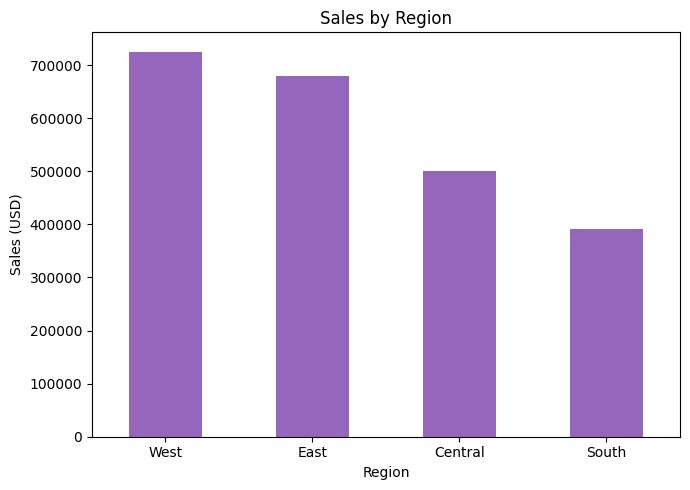

In [10]:
region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
region.plot(kind='bar', color='#9467bd')
plt.title('Sales by Region')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()

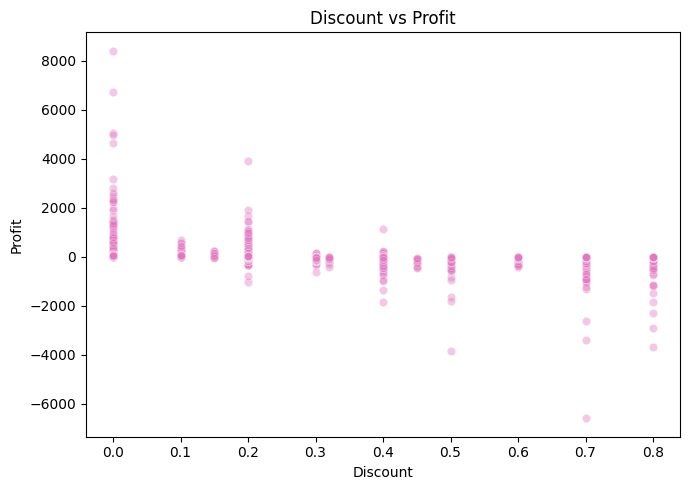

Correlation: -0.22


In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='#e377c2')
plt.title('Discount vs Profit')
plt.tight_layout()
plt.savefig('discount_profit.png')
plt.show()
print("Correlation:", df['Discount'].corr(df['Profit']).round(2))


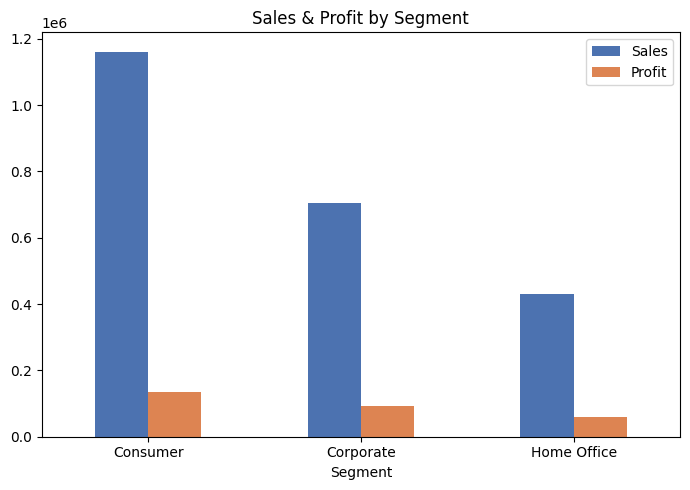

In [12]:
seg = df.groupby('Segment')[['Sales','Profit']].sum().reset_index()
seg.plot(x='Segment', kind='bar', figsize=(7,5), color=['#4C72B0','#DD8452'])
plt.title('Sales & Profit by Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('segment_analysis.png')
plt.show()

In [13]:
from google.colab import files

files.download('category_sales_profit.png')
files.download('monthly_trend.png')
files.download('subcategory_profit.png')
files.download('region_sales.png')
files.download('discount_profit.png')
files.download('segment_analysis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>